In [1]:
pwd

'c:\\ml_eng_prep_2026\\project-1-secom-yield\\notebooks'

In [2]:
import pandas as pd 

X = pd.read_csv("../data/secom.data", sep = r"\s+", header = None)
labels = pd.read_csv("../data/secom_labels.data", sep = r"\s+", header = None)

In [3]:
print(X.shape)
print(labels.shape)
print(labels.head())
X.head()

(1567, 590)
(1567, 2)
   0                    1
0 -1  19/07/2008 11:55:00
1 -1  19/07/2008 12:32:00
2  1  19/07/2008 13:17:00
3 -1  19/07/2008 14:43:00
4 -1  19/07/2008 15:22:00


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [4]:
print(labels[0].value_counts())
y = labels[0].map({-1:0, 1:1})
print(y.value_counts())

0
-1    1463
 1     104
Name: count, dtype: int64
0
0    1463
1     104
Name: count, dtype: int64


In [5]:
print(X.dtypes.value_counts())

float64    590
Name: count, dtype: int64


In [6]:
X.isna().mean()

0      0.003829
1      0.004467
2      0.008934
3      0.008934
4      0.008934
         ...   
585    0.000638
586    0.000638
587    0.000638
588    0.000638
589    0.000638
Length: 590, dtype: float64

In [7]:
missing_frac = X.isna().mean().sort_values(ascending = False)

print(missing_frac.head(15))
print((missing_frac>0).sum())
print((missing_frac>0.5).sum())

292    0.911934
293    0.911934
158    0.911934
157    0.911934
492    0.855775
85     0.855775
358    0.855775
220    0.855775
244    0.649649
517    0.649649
109    0.649649
246    0.649649
383    0.649649
382    0.649649
384    0.649649
dtype: float64
538
28


In [17]:
missing_frac[missing_frac>0.5]

292    0.911934
293    0.911934
158    0.911934
157    0.911934
492    0.855775
85     0.855775
358    0.855775
220    0.855775
244    0.649649
517    0.649649
109    0.649649
246    0.649649
383    0.649649
382    0.649649
384    0.649649
245    0.649649
111    0.649649
110    0.649649
516    0.649649
518    0.649649
580    0.605616
578    0.605616
579    0.605616
581    0.605616
73     0.506701
345    0.506701
72     0.506701
346    0.506701
dtype: float64

In [8]:
n_unique = X.nunique()
stds = X.std()

near_constant = (n_unique<=1) | (stds<=1e-6)

print(f"near constant features: {near_constant.sum()}")
print("both near_constant and >50% missing", (near_constant & (missing_frac > 0.5)).sum())

near constant features: 116
both near_constant and >50% missing 0


**Missingness and near-constant features (full dataset)**

- **Missingness:** 538 of 590 features have at least one missing value, so missing data is the norm, not the exception. Dropping rows isn't an option; the pipeline needs an imputation step.
- **Mostly-empty features:** 28 features are more than 50% missing. Most of their values would be imputed guesses rather than real measurements, so they are drop candidates.
- **Near-constant features:** 116 features have one unique value or a standard deviation below 1e-6, so they carry no information to separate pass from fail. They are also drop candidates.
- **No overlap:** none of the 116 near-constant features are among the 28 mostly-empty ones, so dropping both removes 144 features and leaves about 446.
- **Caveat:** these counts use all 1567 rows. The actual drop rules will be fit on the training split only (Week 2), so the final numbers may shift slightly.

In [15]:
counts = y.value_counts()
ratio = counts[0] / counts[1]

print(f"pass:fail ratio is {ratio}")
print(f"fail rate is {y.mean()}")

pass:fail ratio is 14.067307692307692
fail rate is 0.06636885768985322


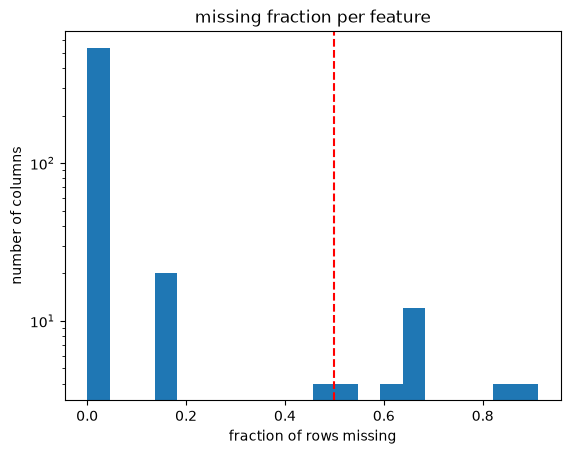

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.yscale("log")
plt.hist(missing_frac, bins = 20)
plt.axvline(0.5, color = "red", linestyle="--")
plt.xlabel("fraction of rows missing")
plt.ylabel("number of columns")
plt.title("missing fraction per feature")
plt.show()

In [29]:
tail = missing_frac[missing_frac>0.1].round(3)
print(tail.value_counts().sort_index())

0.166    12
0.174     8
0.456     4
0.507     4
0.606     4
0.650    12
0.856     4
0.912     4
Name: count, dtype: int64


**What this means for modelling**

- **Imbalance (~14:1):** 1463 pass vs 104 fail, a 6.6% fail rate. A model that predicts "pass" for every wafer would be ~93% accurate while catching zero failures, so accuracy is not a usable metric here. Evaluation has to focus on the fail class: precision, recall, F1 and ROC-AUC.
- **Missingness is widespread:** 538 of 590 features have at least one missing value, so dropping rows with missing values would throw away most of the data. Imputation is required, and it must be fit on the training split only to avoid leaking test information.
- **Missingness is grouped, not random:** the features with more than 10% missing fall into only 8 distinct missing rates, in groups of 4, 8 or 12 features, which suggests sensor groups that go offline together. Two groups sit near the 50% drop threshold (45.6% and 50.7%), so the 50.7% group could fall below 0.5 when recomputed on the training split. The threshold choice needs rechecking in Week 2.